In [1]:
from datetime import datetime
from arcgis.features import FeatureCollection
from arcgis.gis import Item
from arcgis.geoprocessing._job import GPJob

In [2]:
from arcgis.gis import GIS
# gis = GIS(profile='your_online_profile')
gis = GIS(profile='your_enterprise_profile')

In [3]:
gis

GIS @ https://pythonapi.playground.esri.com/portal version:9.2

In [4]:
from arcgis.features.use_proximity import create_drive_time_areas

In [5]:
# office_item = gis.content.get('1f163950afbb4bf39f3ee67cf411761d') # Online
office_item = gis.content.get('c0659bb33db74a9d99e3490481f4407f') # Enterprise
airport_item = gis.content.get('5d93352406744d658d9c1f43f12b560c')

<Item title:"US_Regional_Offices" type:Feature Layer Collection owner:arcgispyapibot>
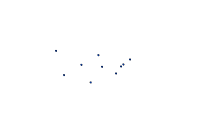

In [6]:
office_item

<Item title:"USA Airports" type:Feature Layer Collection owner:esri_livingatlas>
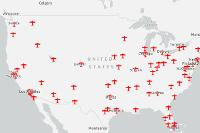

In [7]:
airport_item

In [8]:
esri_offices = office_item.layers[0]
airport_lyr = airport_item.layers[0]

In [9]:
from datetime import datetime
target_area1 = create_drive_time_areas(esri_offices,
                                       output_name='create_drive_time_areas_test_1' + str(datetime.now().microsecond),
                                       future=True)

Travel mode not set, using default travel mode


In [10]:
assert isinstance(target_area1, GPJob)
target_area1

<CreateDriveTimeAreas GP Job: j1723865da53c4ca99636005bf813bc79>

In [11]:
assert isinstance(target_area1.result(), Item)
target_area1.result()

Invalid value for parameter inputLayer - Details : Accessing URL https://pythonapi.playground.esri.com/server/rest/services/Hosted/US_Regional_Offices/FeatureServer/0 failed with error Proxy server got bad address from remote server (verify the server is running). (status code 504).. 
Failed.


Exception: Job failed.

In [ ]:
target_area1.result().delete()

In [13]:
target_area2 = create_drive_time_areas(esri_offices,
                                       break_values=[2],
                                       break_units='Hours',
                                       travel_mode='Driving Time',
                                       overlap_policy='Overlap',
                                       time_of_day=datetime(1990, 1, 4, 1, 3), 
                                       output_name='create_drive_time_areas_test_2' + str(datetime.now().microsecond))

Invalid value for parameter inputLayer - Details : Accessing URL https://pythonapi.playground.esri.com/server/rest/services/Hosted/US_Regional_Offices/FeatureServer/0 failed with error Proxy server got bad address from remote server (verify the server is running). (status code 504).. 
Failed.


Exception: Job failed.

In [ ]:
assert isinstance(target_area2, Item)
target_area2

In [ ]:
target_area2.delete()

In [14]:
target_area3 = create_drive_time_areas(airport_lyr,
                                       break_values=[2, 4],
                                       break_units='Minutes',
                                       travel_mode='Walking Time',
                                       overlap_policy='Dissolve',  
                                       output_name='create_drive_time_areas_test_3' + str(datetime.now().microsecond))

ERROR 089138: Failed to create Feature Service - .
{"messageCode": "AO_100028", "message": "CreateDriveTimeAreas failed."}
Failed to execute (CreateDriveTimeAreas).
Failed.


Exception: Job failed.

In [ ]:
assert isinstance(target_area3, Item)
target_area3

In [ ]:
target_area3.delete()

In [15]:
target_area4 = create_drive_time_areas(airport_lyr,
                                       break_values=[2, 4],
                                       break_units='Hours',
                                       travel_mode='Trucking Time',
                                       overlap_policy='Split',  
                                       time_of_day=datetime(2019, 5, 13, 7, 52),
                                       output_name='create_drive_time_areas_test_4' + str(datetime.now().microsecond),
                                       context={"extent":{"xmin":-11134400.655784884,"ymin":3368261.7800108367,"xmax":-10682810.692676282,"ymax":3630899.409198575,"spatialReference":{"wkid":102100,"latestWkid":3857}}})

ERROR 089138: Failed to create Feature Service - .
{"messageCode": "AO_100028", "message": "CreateDriveTimeAreas failed."}
Failed to execute (CreateDriveTimeAreas).
Failed.


Exception: Job failed.

In [ ]:
assert isinstance(target_area4, Item)
target_area4

In [ ]:
target_area4.delete()

In [16]:
target_area5 = create_drive_time_areas(esri_offices)

Invalid value for parameter inputLayer - Details : Accessing URL https://pythonapi.playground.esri.com/server/rest/services/Hosted/US_Regional_Offices/FeatureServer/0 failed with error Proxy server got bad address from remote server (verify the server is running). (status code 504).. 
Failed.


Exception: Job failed.

In [ ]:
assert isinstance(target_area5, FeatureCollection)
target_area5

In [17]:
target_area6 = create_drive_time_areas(esri_offices, future=True)
assert isinstance(target_area6.result(), FeatureCollection)
target_area6

Invalid value for parameter inputLayer - Details : Accessing URL https://pythonapi.playground.esri.com/server/rest/services/Hosted/US_Regional_Offices/FeatureServer/0 failed with error Proxy server got bad address from remote server (verify the server is running). (status code 504).. 
Failed.


Exception: Job failed.

In [18]:
target_area7 = create_drive_time_areas(esri_offices,
                                       output_name="create_drive_time_areas_test_7" + str(datetime.now().microsecond),
                                       include_reachable_streets=True)

Invalid value for parameter inputLayer - Details : Accessing URL https://pythonapi.playground.esri.com/server/rest/services/Hosted/US_Regional_Offices/FeatureServer/0 failed with error Proxy server got bad address from remote server (verify the server is running). (status code 504).. 
Failed.


Exception: Job failed.

In [ ]:
assert isinstance(target_area7, Item)
assert len(target_area7.layers) == 2
assert target_area7.layers[1].properties.name == "Reachable Streets"

In [ ]:
target_area7.delete()

In [ ]:
target_area8 = create_drive_time_areas(esri_offices,
                                       travel_mode="Driving Distance",
                                       break_values=[1,2,3],
                                       break_units="Miles",
                                       include_reachable_streets=True,
                                       output_name="create_drive_time_areas_test_8" + str(datetime.now().microsecond),
                                       future=True)

In [ ]:
target_area8.result()

In [ ]:
target_area8.result().delete()